In [1]:

import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_Liver_CAW009/')

/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_34228/4034718418.py:1: UserWarning: Multiple 

In [3]:
sdata

SpatialData object
├── Images
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│     └── 'CAW009_square_032um': GeoDataFrame shape: (28319, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (6931516, 19059)
      ├── 'square_008um': AnnData (437010, 19059)
      ├── 'square_016um': AnnData (110518, 19059)
      └── 'square_032um': AnnData (28319, 19059)
with coordinate systems:
    ▸ 'downscaled

In [4]:
# Get key names of all tables
for adata_key in sdata.tables.keys():
    sdata.tables[adata_key].var_names_make_unique()

INFO     Rasterizing image for faster rendering.                                                                   


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.125..1.0].


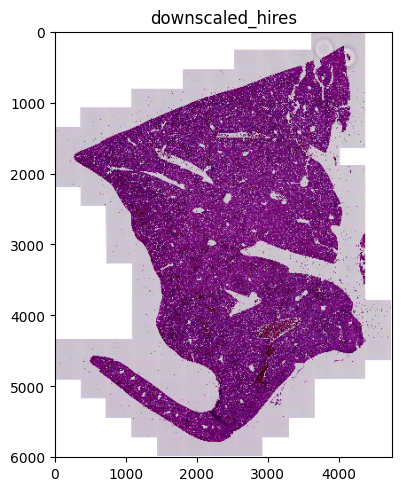

In [4]:
sdata.pl.render_images("CAW009_hires_image").pl.show(coordinate_systems="downscaled_hires")

Let's work with a subset of the data

In [5]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[2000, 2000], max_coordinate=[3000, 3000], axes=("x", "y"), target_coordinate_system="downscaled_hires"
)

In [8]:
print('Acvrl1' in sdata.tables['square_008um'].var_names)
print('Gdf2' in sdata.tables['square_008um'].var_names)
print('Bmp10' in sdata.tables['square_008um'].var_names)

True
True
True


### Gene expression

In [10]:
adata = sdata.tables['square_008um']

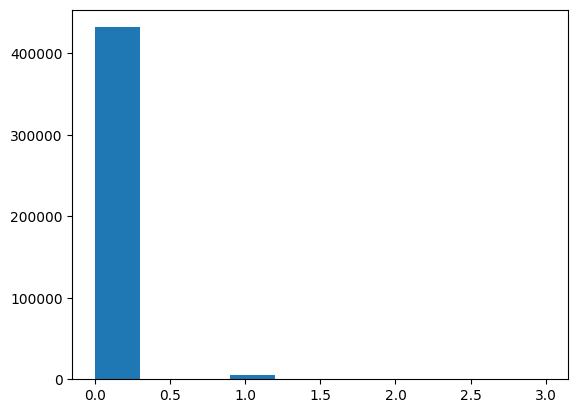

In [11]:
# Get distribution of  expression in adata
gene = adata.X[:, adata.var_names == 'Acvrl1']

# Convert to vector
gene = gene.toarray().reshape(-1)

# plot histogram
import matplotlib.pyplot as plt
plt.hist(gene, bins=10)
plt.show()


In [12]:
# Count number of cells with Hnrnpa1 expression > 0
num_cells = sum(gene > 0)
num_cells

5131

In [11]:
# Create dataframe from the vector
import pandas as pd
df = pd.DataFrame(gene, columns=['Clec4f'])

In [12]:
df['Clec4f'].describe()

count    437010.000000
mean          0.431002
std           1.086543
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: Clec4f, dtype: float64

In [13]:
df['Clec4f'].value_counts()

Clec4f
0.0     336010
1.0      61256
2.0      19648
3.0       8920
4.0       4716
5.0       2613
6.0       1532
7.0        881
8.0        553
9.0        332
10.0       220
11.0       129
12.0        76
13.0        52
14.0        32
15.0        14
17.0         7
16.0         6
18.0         5
19.0         3
21.0         2
24.0         2
23.0         1
Name: count, dtype: int64

In [16]:
sdata_small["square_016um"].var_names_make_unique()

INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


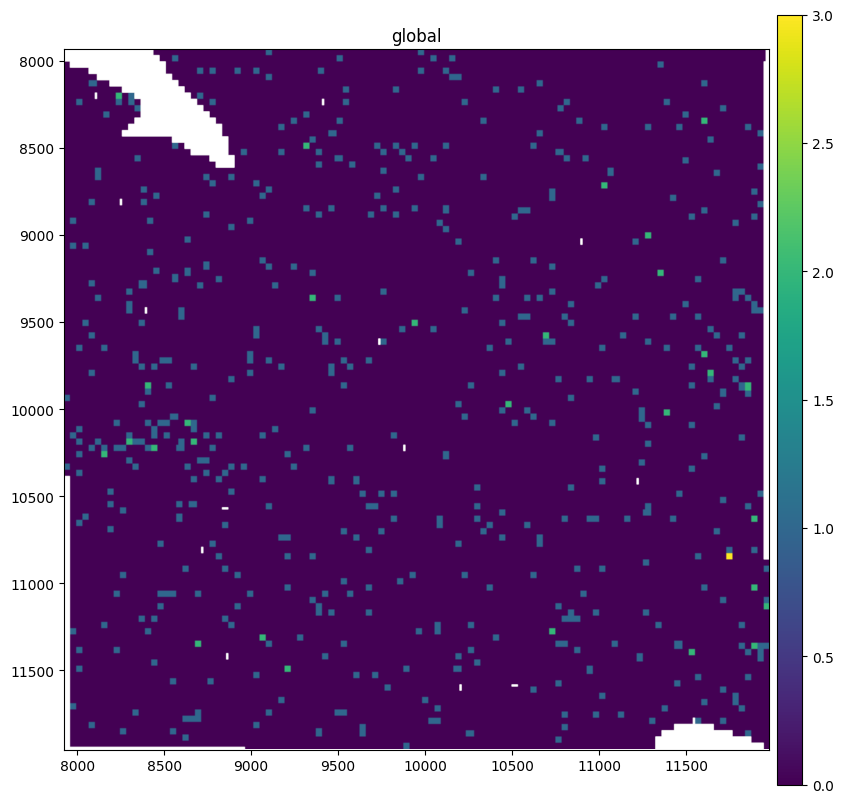

In [27]:
# Plot expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Acvrl1"
sdata_small.pl.render_shapes("CAW009_square_016um", color=gene_name, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.
INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


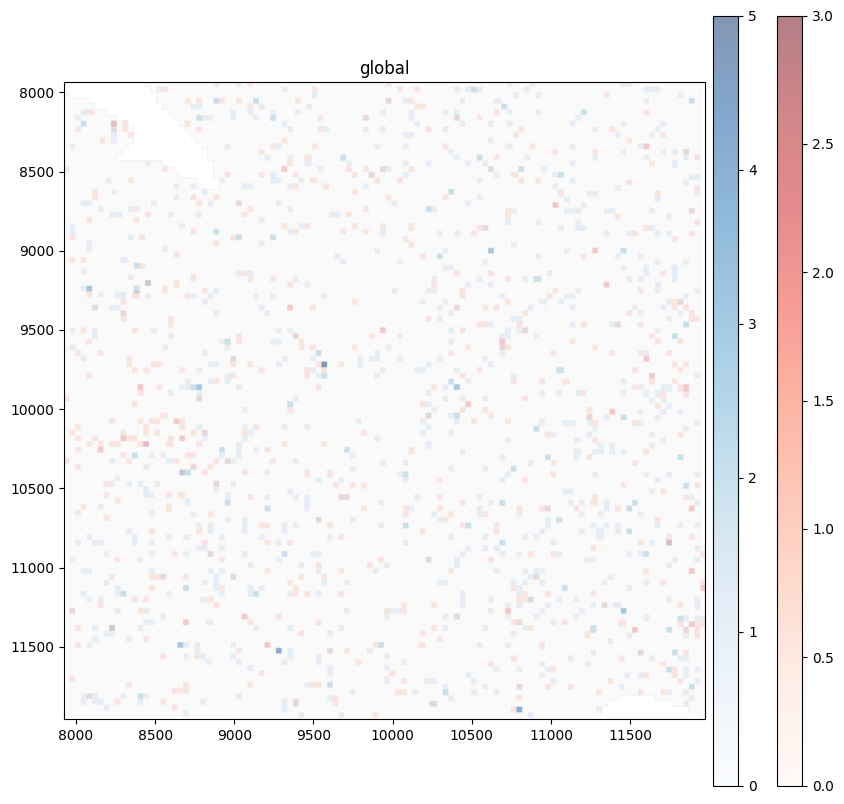

In [36]:
# Plot expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Gdf2"
sdata_small.pl.render_shapes("CAW009_square_016um", color="Acvrl1", cmap='Reds', fill_alpha=0.5, method="datashader").\
    pl.render_shapes("CAW009_square_016um", color="Gdf2", cmap='Blues', fill_alpha=0.5, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.
INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


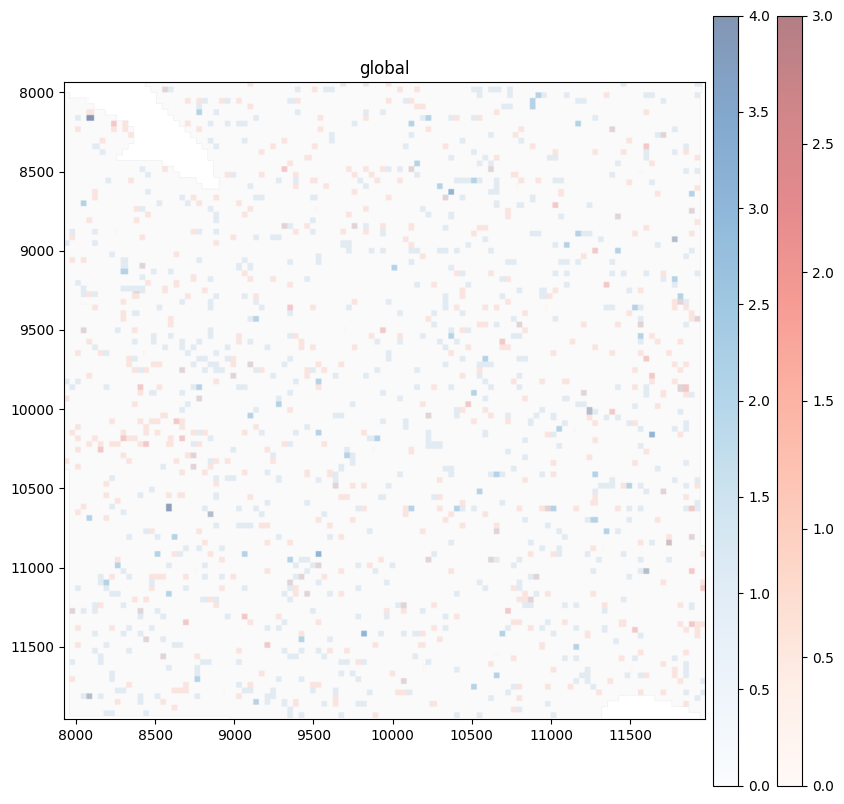

In [37]:
# Plot expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Gdf2"
sdata_small.pl.render_shapes("CAW009_square_016um", color="Acvrl1", cmap='Reds', fill_alpha=0.5, method="datashader").\
    pl.render_shapes("CAW009_square_016um", color="Bmp10", cmap='Blues', fill_alpha=0.5, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


In [42]:
# Read in visium_hd_liver/final_MERscope_panel_Guilliams1.csv
marker_genes = pd.read_csv('final_MERscope_panel_Guilliams1.csv')

# Print the first few rows of the marker_genes dataframe
print(marker_genes.head())


# Get value_counts of "Notes" column that starts with cellType_
print(marker_genes['Notes'][marker_genes['Notes'].str.startswith('cellType_')].value_counts())

# Only get marker genes with cellType_ in the "Notes" column that has more than 10 genes
marker_genes_subset = marker_genes[marker_genes['Notes'].str.startswith('cellType_KC')].copy()
print(marker_genes_subset)

  Gene Input Vizgen Gene         Ensemble ID          Transcript  \
0       NGFR        Ngfr  ENSMUSG00000000120  ENSMUST00000000122   
1       CCL2        Ccl2  ENSMUSG00000035385  ENSMUST00000000193   
2      CCL12       Ccl12  ENSMUSG00000035352  ENSMUST00000000194   
3         TH          Th  ENSMUSG00000000214  ENSMUST00000000219   
4       LHX2        Lhx2  ENSMUSG00000000247  ENSMUST00000000253   

                         Notes  Abundance  Target Regions     Type  
0     zonation_portal_stellate   0.633947             102  MERFISH  
1        partialHepatectomy_KC   1.699000              57  MERFISH  
2  partialHepatectomy_monocyte   0.084735              40  MERFISH  
3            neuron_adrenergic   0.027851              51  MERFISH  
4            cellType_stellate   0.532331              55  MERFISH  
Notes
cellType_stellate              35
cellType_LSEC                  33
cellType_fibroblast            32
cellType_KC                    28
cellType_TCell                 27
c

In [ ]:
# Sort marker_genes_subset by Abundance
# From Ruth: Clec4f, CD5L, Vsig4
marker_genes_subset.sort_values(by='Abundance', ascending=False)


,Gene Input,Vizgen Gene,Ensemble ID,Transcript,Notes,Abundance,Target Regions,Type
51,ID3,Id3,ENSMUSG00000007872,ENSMUST00000008016,cellType_KC,42.677302,56,MERFISH
63,CLEC4F,Clec4f,ENSMUSG00000014542,ENSMUST00000014686,cellType_KC,31.877110,62,MERFISH
74,CD5L,Cd5l,ENSMUSG00000015854,ENSMUST00000015998,cellType_KC,23.095092,64,MERFISH
159,SLC40A1,Slc40a1,ENSMUSG00000025993,ENSMUST00000027137,cellType_KC,22.562802,76,MERFISH
379,VSIG4,Vsig4,ENSMUSG00000044206,ENSMUST00000050707,cellType_KC,17.535685,51,MERFISH
610,NCOA4,Ncoa4,ENSMUSG00000056234,ENSMUST00000111994,cellType_KC,9.192397,99,MERFISH
73,LPL,Lpl,ENSMUSG00000015568,ENSMUST00000015712,cellType_KC,6.501453,110,MERFISH
38,HMOX1,Hmox1,ENSMUSG00000005413,ENSMUST00000005548,cellType_KC,4.990919,58,MERFISH
92,FABP7,Fabp7,ENSMUSG00000019874,ENSMUST00000020024,cellType_KC,4.617409,61,MERFISH
575,IRF7,Irf7,ENSMUSG00000025498,ENSMUST00000106023,cellType_KC,4.150706,69,MERFISH


INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


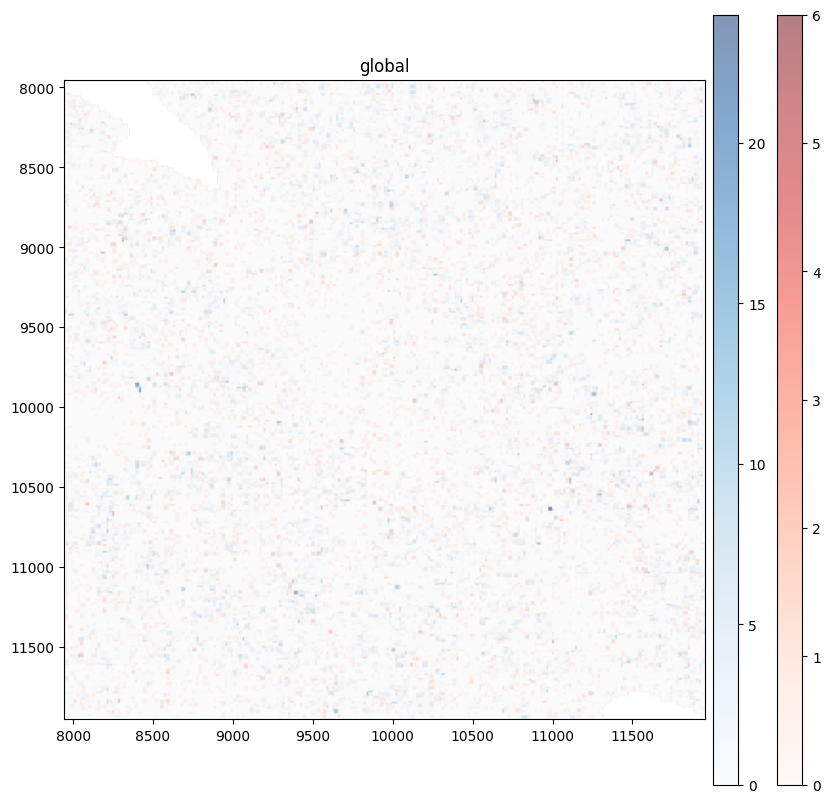

In [46]:
# Plot expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Gdf2"
sdata_small.pl.render_shapes("CAW009_square_008um", color="Id3", cmap='Reds', fill_alpha=0.5, method="datashader").\
    pl.render_shapes("CAW009_square_008um", color="Clec4f", cmap='Blues', fill_alpha=0.5, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


In [6]:
def calculate_coexpression(gene1, gene2):
    # How many percent of the spots express both gene1 and gene2?
    num_spots = sdata_small.tables['square_008um'].shape[0]
    num_spots_with_both = sum((sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene1] > 0).todense() &
                            (sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene2] > 0).todense())[0,0]

    # How many percent of the spots express only gene1?
    num_spots_with_only_gene1 = sum((sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene1] > 0).todense() &
                                    (sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene2] == 0).todense())[0,0]

    # How many percent of the spots express only gene2?
    num_spots_with_only_gene2 = sum((sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene2] > 0).todense() &
                                        (sdata_small.tables['square_008um'].X[:, sdata_small.tables['square_008um'].var_names == gene1] == 0).todense())[0,0]

    # How many percent of the spots express neither?
    num_spots_with_neither = num_spots - (num_spots_with_both + num_spots_with_only_gene1 + num_spots_with_only_gene2)

    percent_with_both = num_spots_with_both / num_spots * 100
    percent_with_only_gene1 = num_spots_with_only_gene1 / num_spots * 100
    percent_with_only_gene2 = num_spots_with_only_gene2 / num_spots * 100
    percent_with_neither = num_spots_with_neither / num_spots * 100

    print(f"Percent of spots with both {gene1} and {gene2}: {percent_with_both:.2f}%")
    print(f"Percent of spots with only {gene1}: {percent_with_only_gene1:.2f}%")
    print(f"Percent of spots with only {gene2}: {percent_with_only_gene2:.2f}%")
    print(f"Percent of spots with neither: {percent_with_neither:.2f}%")

In [7]:
calculate_coexpression('Cd5l', 'Clec4f')

/tmp/ipykernel_34228/1025403252.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Cd5l', 'Clec4f')


Percent of spots with both Cd5l and Clec4f: 13.96%
Percent of spots with only Cd5l: 12.90%
Percent of spots with only Clec4f: 10.54%
Percent of spots with neither: 62.61%


In [8]:
calculate_coexpression('Vsig4', 'Clec4f')

/tmp/ipykernel_34228/3763573473.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Vsig4', 'Clec4f')


Percent of spots with both Vsig4 and Clec4f: 8.40%
Percent of spots with only Vsig4: 5.91%
Percent of spots with only Clec4f: 16.10%
Percent of spots with neither: 69.60%


In [9]:
calculate_coexpression('Cd5l', 'Vsig4')

/tmp/ipykernel_34228/3009356004.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Cd5l', 'Vsig4')


Percent of spots with both Cd5l and Vsig4: 8.86%
Percent of spots with only Cd5l: 17.99%
Percent of spots with only Vsig4: 5.44%
Percent of spots with neither: 67.71%


In [78]:
calculate_coexpression('Acvrl1', 'Gdf2')

/tmp/ipykernel_169786/101016884.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Acvrl1', 'Gdf2')


Percent of spots with both Acvrl1 and Gdf2: 0.03%
Percent of spots with only Acvrl1: 1.14%
Percent of spots with only Gdf2: 1.85%
Percent of spots with neither: 96.98%


In [79]:
calculate_coexpression('Acvrl1', 'Bmp10')

/tmp/ipykernel_169786/1985966726.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Acvrl1', 'Bmp10')


Percent of spots with both Acvrl1 and Bmp10: 0.04%
Percent of spots with only Acvrl1: 1.13%
Percent of spots with only Bmp10: 1.63%
Percent of spots with neither: 97.20%


In [80]:
calculate_coexpression('Vsig4', 'Clec4f')

/tmp/ipykernel_169786/3763573473.py:1: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  calculate_coexpression('Vsig4', 'Clec4f')


Percent of spots with both Vsig4 and Clec4f: 8.40%
Percent of spots with only Vsig4: 5.91%
Percent of spots with only Clec4f: 16.10%
Percent of spots with neither: 69.60%


In [5]:
sdata

SpatialData object
├── Images
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│     └── 'CAW009_square_032um': GeoDataFrame shape: (28319, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (6931516, 19059)
      ├── 'square_008um': AnnData (437010, 19059)
      ├── 'square_016um': AnnData (110518, 19059)
      └── 'square_032um': AnnData (28319, 19059)
with coordinate systems:
    ▸ 'downscaled

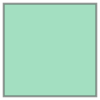

In [20]:
sdata.shapes['CAW009_square_008um'].iloc[0].geometry